In [10]:
import os, numpy as np, matplotlib.pyplot as plt, rampy as rp, pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from itertools import combinations
from scipy.stats import ttest_ind

In [3]:
os.chdir("../drug_test_spontaneous/")

In [4]:
os.getcwd()

'/mnt/d/Work/UCSD/Shi_lab/Donepezil_project/drug_test_spontaneous'

In [15]:
def plot_raman_txt(path, clip_below_zero=True, ax=None, label=None, **plot_kwargs):
    data = np.loadtxt(path)
    if data.ndim != 2 or data.shape[1] < 2:
        raise ValueError(f"Expected at least 2 columns in {path}, got shape {data.shape}")

    shift = data[:, 0]
    intensity = data[:, 1]

    if clip_below_zero:
        intensity = np.where(intensity < 0, 0.0, intensity)

    # L2 normalization
    norm = np.linalg.norm(intensity)
    if norm != 0:
        intensity = intensity / norm

    if ax is None:
        _, ax = plt.subplots()

    if label is None:
        label = os.path.basename(path)

    ax.plot(shift, intensity, label=label, **plot_kwargs)
    ax.set_xlabel("Raman shift (cm$^{-1}$)")
    ax.set_ylabel("L2-normalized intensity")
    ax.legend()

    return shift, intensity, ax

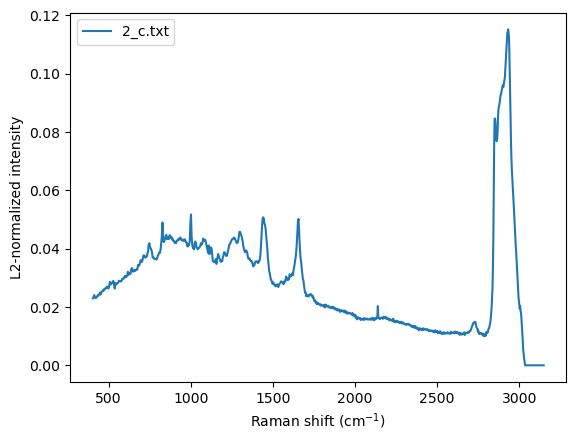

In [18]:
shift, inten, ax = plot_raman_txt("../drug_test_spontaneous/day7/1mm/2_c.txt")
plt.show()

### Background Subtraction Test

In [13]:
def process_and_plot_raman(raw_txt_path, background_txt_path,
                           title="Background-subtracted, L2-normalized Raman spectra"):

    def _read_txt(path):
        # Handles tab, spaces, or comma-separated text
        df = pd.read_csv(
            path,
            sep=r"[\s,]+",
            engine="python",
            header=None,
            comment="#"
        ).dropna(axis=1, how="all")

        if df.shape[1] < 2:
            raise ValueError(
                f"{path} must contain at least 2 columns: Raman shift + intensity."
            )

        shifts = df.iloc[:, 0].to_numpy(dtype=float)
        intensities = df.iloc[:, 1:].to_numpy(dtype=float)
        return shifts, intensities

    raw_shifts, raw_intensity = _read_txt(raw_txt_path)
    bg_shifts, bg_intensity = _read_txt(background_txt_path)

    # If multiple background spectra are present, average them
    if bg_intensity.shape[1] > 1:
        bg_intensity = bg_intensity.mean(axis=1, keepdims=True)

    # Interpolate background to raw shift axis if needed
    if (
        len(raw_shifts) != len(bg_shifts)
        or not np.allclose(raw_shifts, bg_shifts, rtol=0, atol=1e-8)
    ):
        bg_interp = np.column_stack([
            np.interp(raw_shifts, bg_shifts, bg_intensity[:, i])
            for i in range(bg_intensity.shape[1])
        ])
    else:
        bg_interp = bg_intensity

    # Broadcast one background trace to all raw spectra if needed
    if bg_interp.shape[1] == 1:
        bg_to_subtract = np.repeat(bg_interp, raw_intensity.shape[1], axis=1)
    elif bg_interp.shape[1] == raw_intensity.shape[1]:
        bg_to_subtract = bg_interp
    else:
        raise ValueError(
            "Background file must contain either 1 background spectrum "
            "or the same number of spectra as the raw file."
        )

    # Background subtraction
    processed = raw_intensity - bg_to_subtract

    # L2 normalization for each spectrum
    norms = np.linalg.norm(processed, axis=0, keepdims=True)
    norms[norms == 0] = 1.0
    processed_norm = processed / norms

    # Plot
    plt.figure(figsize=(8, 5))
    for i in range(processed_norm.shape[1]):
        label = "Processed spectrum" if processed_norm.shape[1] == 1 else f"Spectrum {i+1}"
        plt.plot(raw_shifts, processed_norm[:, i], linewidth=1.5, label=label)

    plt.xlabel("Raman shift")
    plt.ylabel("Normalized intensity")
    plt.title(title)
    if processed_norm.shape[1] > 1:
        plt.legend(frameon=False)
    plt.tight_layout()

    return raw_shifts, processed_norm

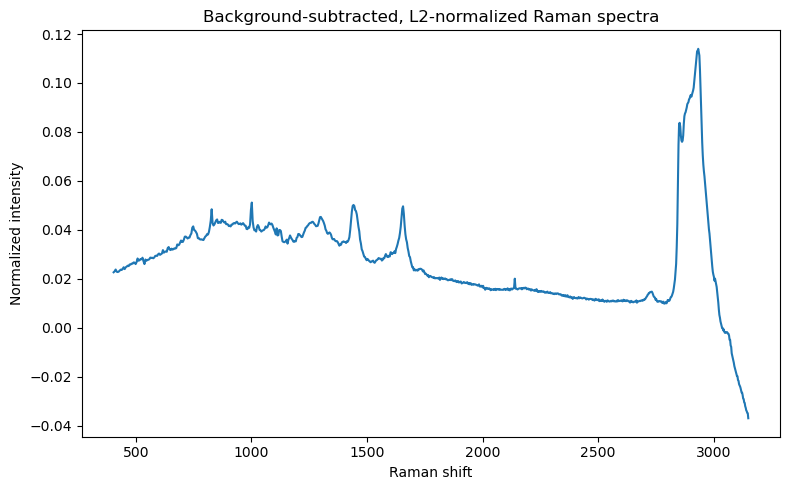

In [17]:
raw_shifts, processed_norm = process_and_plot_raman("day7/1mm/2.txt", "day7/1mm/background.txt")

### L2 normalization

In [4]:
def best_shift_cos(x_ref, y_ref, x, y, region=(2800, 3050), shifts=np.arange(-80, 81, 1), eps=1e-12):
    m = (x_ref >= region[0]) & (x_ref <= region[1])
    xr = x_ref[m]

    yr = np.interp(xr, x_ref, y_ref)
    yr = yr - yr.mean()
    yr = yr / (np.linalg.norm(yr) + eps)

    best_s, best_c = 0.0, -1.0
    for s in shifts:
        ys = np.interp(xr, x + s, y, left=0.0, right=0.0)
        ys = ys - ys.mean()
        ys = ys / (np.linalg.norm(ys) + eps)
        c = float(yr @ ys)  # cosine similarity
        if c > best_c:
            best_c, best_s = c, float(s)
    return best_s, best_c

In [16]:
def bh_fdr(pvals):
    """Benjamini–Hochberg FDR. Returns q-values (same shape as pvals)."""
    p = np.asarray(pvals, float)
    m = p.size
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * m / (np.arange(1, m + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]  # enforce monotone
    out = np.empty_like(q)
    out[order] = np.clip(q, 0, 1)
    return out


In [ ]:
def plot_avg_raman_dirs(
    dirs, labels, band_k=None, alpha=0.3,
    title="Raman spectra", normalize=True, eps=1e-12, detailed=False,
    align=True, align_region=(2800, 3050), shift_max=100, shift_step=1,
    save_path=None,
    # ---- NEW: global normalization range ----
    normalize_range=(600, 3050),
    # ---- stats ----
    do_ttest=True, p_thresh=0.05, top_n=10, fdr_bh=True
):
    # ---------- global x_ref ----------
    d0_files = sorted([os.path.join(dirs[0], f) for f in os.listdir(dirs[0]) if f.endswith("c.txt")])
    if not d0_files:
        raise ValueError(f"No *c.txt files in {dirs[0]}")
    x_ref = np.loadtxt(d0_files[0])[:, 0]

    def _shift_y(y, s_cm):
        return np.interp(x_ref + s_cm, x_ref, y, left=0.0, right=0.0)

    def _cosine(a, b):
        a = a - a.mean()
        b = b - b.mean()
        return float((a @ b) / ((np.linalg.norm(a) + eps) * (np.linalg.norm(b) + eps)))

    def _best_shift(ref_y, y):
        m = (x_ref >= align_region[0]) & (x_ref <= align_region[1])
        shifts = np.arange(-shift_max, shift_max + shift_step, shift_step)
        best_s, best_c = 0.0, -1e9
        for s in shifts:
            y_s = _shift_y(y, s)
            c = _cosine(ref_y[m], y_s[m])
            if c > best_c:
                best_c, best_s = c, float(s)
        return best_s

    # ---------- load each folder -> keep replicate spectra Y (un-normalized) ----------
    folder_data = []
    for d in dirs:
        files = sorted([os.path.join(d, f) for f in os.listdir(d) if f.endswith("c.txt")])
        if not files:
            raise ValueError(f"No *c.txt files in {d}")

        Y = np.zeros((x_ref.size, len(files)))
        for i, f in enumerate(files):
            spec = np.loadtxt(f)
            Y[:, i] = rp.resample(spec[:, 0], spec[:, 1], x_ref)

        folder_data.append({"Y": Y})

    # ---------- align ALL spectra to folder 0 mean ----------
    shifts_used = [0.0] * len(dirs)

    # reference mean (un-normalized) for alignment
    ref_mean = folder_data[0]["Y"].mean(axis=1)

    if align:
        for k in range(1, len(dirs)):
            Y = folder_data[k]["Y"]
            mean_k = Y.mean(axis=1)
            s = _best_shift(ref_mean, mean_k)
            shifts_used[k] = s

            Y_shift = np.zeros_like(Y)
            for j in range(Y.shape[1]):
                Y_shift[:, j] = _shift_y(Y[:, j], s)
            folder_data[k]["Y"] = Y_shift

    # ---------- GLOBAL L2-normalize each replicate spectrum ONCE ----------
    if normalize:
        mn = (x_ref >= normalize_range[0]) & (x_ref <= normalize_range[1])
        for dct in folder_data:
            Y = dct["Y"]
            norms = np.linalg.norm(Y[mn, :], axis=0) + eps  # per replicate
            dct["Y"] = Y / norms[None, :]

    # ---------- compute mean + SE bands from normalized replicates ----------
    for dct in folder_data:
        Y = dct["Y"]
        n = Y.shape[1]
        mean = Y.mean(axis=1)
        std = Y.std(axis=1, ddof=1) if n > 1 else np.zeros_like(mean)
        se = std / np.sqrt(max(n, 1))

        # keep non-negative for display if you want (optional; comment out if undesired)
        mean_plot = np.maximum(mean, 0.0)

        if band_k is not None:
            lo = np.maximum(mean_plot - band_k * se, 0.0)
            hi = np.maximum(mean_plot + band_k * se, 0.0)
        else:
            lo = hi = None

        dct["mean"] = mean_plot
        dct["lo"] = lo
        dct["hi"] = hi

    # ---------- prepare PDF (if requested) ----------
    pdf = None
    if save_path is not None:
        if not save_path.lower().endswith(".pdf"):
            save_path = f"{save_path}.pdf"
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        pdf = PdfPages(save_path)

    # ---------- region list ----------
    regions = []
    # full-range overview is usually helpful once global-normalized
    regions.append(((normalize_range[0], normalize_range[1]), "Global range"))
    if detailed:
        for start in range(600, 1800, 200):
            end = min(start + 200, 1800)
            regions.append(((start, end), f"Fingerprint {start}-{end}"))
    else:
        regions.append(((600, 1800), "Fingerprint region"))
    regions.append(((1800, 2800), "Silent region"))
    regions.append(((2800, 3050), "CH-stretch region"))

    # ---------- plot + t-test ----------
    for (xmin, xmax), region_name in regions:
        fig, ax = plt.subplots()
        m = (x_ref >= xmin) & (x_ref <= xmax)
        xw = x_ref[m]

        # plot mean + SE band (already global-normalized)
        for dct, label, s in zip(folder_data, labels, shifts_used):
            mean = dct["mean"][m]
            (line,) = ax.plot(xw, mean, label=f"{label} (shift {s:+.0f})")
            if band_k is not None:
                ax.fill_between(xw, dct["lo"][m], dct["hi"][m], alpha=alpha, color=line.get_color())

        ax.set_title(f"{title} – {region_name}")
        ax.set_xlabel("Raman shift (cm$^{-1}$)")
        ax.set_ylabel("Globally L2-normalized intensity" if normalize else "Intensity (a.u.)")
        ax.tick_params(axis="both", labelsize=24)
        ax.legend()
        fig.tight_layout()

        if pdf is not None:
            pdf.savefig(fig)
            plt.close(fig)

        # t-tests on globally normalized replicate values
        if do_ttest:
            Mats = [dct["Y"][m, :].T for dct in folder_data]  # (n_samples, n_points)

            print(f"\n=== {region_name} {xmin}-{xmax} cm^-1 | {'FDR' if fdr_bh else 'raw'} p<{p_thresh} ===")
            for i, j in combinations(range(len(dirs)), 2):
                A, B = Mats[i], Mats[j]
                if A.shape[0] < 2 or B.shape[0] < 2:
                    print(f"- {labels[i]} vs {labels[j]}: skipped (need >=2 spectra per condition)")
                    continue

                t, p = ttest_ind(A, B, axis=0, equal_var=False, nan_policy="omit")
                q = _bh_fdr(p) if fdr_bh else p
                sig = q < p_thresh

                if not np.any(sig):
                    print(f"- {labels[i]} vs {labels[j]}: no significant shifts")
                    continue

                diff = A.mean(axis=0) - B.mean(axis=0)  # mean difference at each shift
                idx = np.where(sig)[0]
                idx = idx[np.argsort(np.abs(diff[idx]))[::-1]]  # rank by |Δ|
                take = idx[:top_n]

                peaks = ", ".join([f"{xw[k]:.1f}(Δ={diff[k]:+.3g}, {'q' if fdr_bh else 'p'}={q[k]:.2g})"
                                   for k in take])
                print(f"- {labels[i]} vs {labels[j]}: {sig.sum()}/{sig.size} sig; top {len(take)}: {peaks}")

    if pdf is not None:
        pdf.close()

    return shifts_used

In [20]:
dirs = ["day35/1mm/", "day35/cl/"]
labels = ["1mM", "Ctrl"]
save_path = "plots/day35.pdf"
plot_avg_raman_dirs(dirs, labels = labels, band_k = 1.0, detailed = True, 
                    align = False, save_path=save_path)


=== Global range 600-3050 cm^-1 | FDR p<0.05 ===
- 1mM vs Ctrl: 4/789 sig; top 4: 2806.1(Δ=+0.0132, q=0.00089), 2803.5(Δ=+0.0122, q=6.2e-06), 2800.9(Δ=+0.00746, q=2.3e-05), 2798.3(Δ=+0.00363, q=0.0051)

=== Fingerprint 600-800 600-800 cm^-1 | FDR p<0.05 ===
- 1mM vs Ctrl: no significant shifts

=== Fingerprint 800-1000 800-1000 cm^-1 | FDR p<0.05 ===
- 1mM vs Ctrl: no significant shifts

=== Fingerprint 1000-1200 1000-1200 cm^-1 | FDR p<0.05 ===
- 1mM vs Ctrl: no significant shifts

=== Fingerprint 1200-1400 1200-1400 cm^-1 | FDR p<0.05 ===
- 1mM vs Ctrl: no significant shifts

=== Fingerprint 1400-1600 1400-1600 cm^-1 | FDR p<0.05 ===
- 1mM vs Ctrl: no significant shifts

=== Fingerprint 1600-1800 1600-1800 cm^-1 | FDR p<0.05 ===
- 1mM vs Ctrl: 2/61 sig; top 2: 1601.8(Δ=+0.00159, q=0.023), 1605.2(Δ=+0.00141, q=0.026)

=== Silent region 1800-2800 cm^-1 | FDR p<0.05 ===
- 1mM vs Ctrl: 1/355 sig; top 1: 2798.3(Δ=+0.00363, q=0.0092)

=== CH-stretch region 2800-3050 cm^-1 | FDR p<0.05 ===

[0.0, 0.0]

In [21]:
dirs = ["day7/1mm/", "day7/cl/"]
labels = ["1mM", "Ctrl"]
save_path = "plots/day7.pdf"
plot_avg_raman_dirs(dirs, labels = labels, band_k = 1.0, detailed = True, 
                    align = False, save_path=save_path)


=== Global range 600-3050 cm^-1 | FDR p<0.05 ===
- 1mM vs Ctrl: no significant shifts

=== Fingerprint 600-800 600-800 cm^-1 | FDR p<0.05 ===
- 1mM vs Ctrl: no significant shifts

=== Fingerprint 800-1000 800-1000 cm^-1 | FDR p<0.05 ===
- 1mM vs Ctrl: 52/52 sig; top 10: 800.2(Δ=+0.015, q=0.035), 827.9(Δ=+0.0148, q=0.035), 808.1(Δ=+0.0142, q=0.035), 804.1(Δ=+0.0141, q=0.035), 816.0(Δ=+0.0138, q=0.035), 812.1(Δ=+0.0137, q=0.035), 913.8(Δ=+0.0134, q=0.035), 824.0(Δ=+0.0134, q=0.035), 820.0(Δ=+0.0131, q=0.035), 831.9(Δ=+0.0129, q=0.035)

=== Fingerprint 1000-1200 1000-1200 cm^-1 | FDR p<0.05 ===
- 1mM vs Ctrl: 55/55 sig; top 10: 1109.0(Δ=+0.0135, q=0.03), 1177.6(Δ=+0.0133, q=0.03), 1188.3(Δ=+0.0129, q=0.03), 1170.5(Δ=+0.0129, q=0.03), 1174.0(Δ=+0.0127, q=0.03), 1050.1(Δ=+0.0127, q=0.03), 1024.0(Δ=+0.0126, q=0.03), 1046.4(Δ=+0.0126, q=0.03), 1138.1(Δ=+0.0126, q=0.03), 1141.7(Δ=+0.0125, q=0.03)

=== Fingerprint 1200-1400 1200-1400 cm^-1 | FDR p<0.05 ===
- 1mM vs Ctrl: 58/58 sig; top 10: 121

[0.0, 0.0]